#### K-Means (평균을 이용한 군집화)
- k개의 그룹으로 자동 분류하는 비지도 학습 알고리즘
- 종속 변수가 존재하지 않는 데이터에서 유사한 데이터끼리 모음 
- 서로 가까운 데이터는 같은 그룹으로 묶어서 그룹화 
- 그룹의 중심점을 반복적으로 계산(중심점의 이동)하여 군집을 형성

- 작업 순서 
    - 초기의 중심점(k개)을 선택 
    - 각각의 데이터들을 중심점과의 거리를 확인
    - 가까운 거리를 중심점을 할당 
    - 각 군집의 평균을 구해서 새로운 중심점을 설정 
    - 중심점의 변화가 거의 없을때까지 반복 실행
- 장점 
    - 빠르고 단순하여 대용량의 데이터에서 적합 
- 단점
    - 군집의 수를 미리 알고 작성해야된다는 점
    - 이상치에 굉장히 민감 
- parameter
    - n_clusters
        - 기본값 : 8
        - 군집의 개수를 지정
        - 너무 작거나 큰 경우에는 성능 저하 가능
    - init 
        - 기본값 : 'k_means++'
        - 초기의 중심점을 설정하는 방법 
        - 기본값을 사용하면 빠르고 안정적 
        - 'random' : 무작위하게 중심점을 설정 
    - n_init
        - 기본값 : 'auto' (구버전 10)
        - 초기화 횟수
        - 초기화하여 여러번의 시도를 통해 최적의 결과를 만드는 방법
    - max_iter
        - 기본값 : 300
        - 한번의 실행에서 최대의 반복 횟수
    - tol
        - 기본값 : 1e-4
        - 중심점의 이동의 변화량이 이 값보다 작은 경우에는 수렴 
    - algosithm
        - 기본값 : 'lloyd'
        - 'elkan' : 속도 향상 (밀집데이터에서 유리)
- 속성
    - coluster_center_
        - 각 군집의 중심점 좌표
    - labels_   
        - 각 데이터의 군집의 번호 
    - inertia_
        - 군집 내의 거리 제곱합
        - 작을수록 군집이 응집되어있음
    - n_iter_
        - 마지막 반복에서의 수행 횟수(중심점 이동 횟수)
- 메서드 
    - fit(X)
        - 모델의 학습
    - predict()
        - 새로운 데이터를 이용하여 군집화 예측
    - transform()
        - 각 데이터와 각 중심점간의 거리를 행렬도 변환하여 출력
    - score()
        - _inertia값을 반환 
    - get_params() / set_params()
- 검증 방법
    - inertia_
        - 군집 내의 거리 제곱합( 작으수록 응집 )
    - silhouette_score (실루엣 점수)
        - 응집도 + 분리도의 종합 점수 (1의 가까울수록 좋음)
    - calinski_Harabasz_score
        - 군집 간의 분산  / 군집 내의 분산 비율 (높을수록 좋음)
    - davies_Bouldin score
        - 군집 간의 유사도 평균 ( 낮을수록 좋음 )
    - adjusted_rand_score
        - 실제의 라벨과 군집의 일치도( 1 = 일지, 0 = 불일치 )

In [1]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pandas as pd 
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, \
                            adjusted_rand_score

In [2]:
iris = pd.read_csv("../csv/iris.csv")

In [3]:
iris.head(1)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa


In [4]:
x = iris.drop('species', axis=1)
y = iris['species']

In [5]:
# 군집화는 일반적으로 Scaler를 사용 
x_std = StandardScaler().fit_transform(x)

In [6]:
# Kmneas 객체 생성 
model = KMeans(
    n_clusters=3, 
    random_state=42, 
    n_init = 10
)

In [7]:
model.fit(x_std)
labels = model.predict(x_std)

In [ ]:
labels

In [10]:
# 검증 지표 (군집이 얼마나 잘 되었는가?)
inertia = model.inertia_
silhouette = silhouette_score(x_std, labels)
calinski = calinski_harabasz_score(x_std, labels)
davies = davies_bouldin_score(x_std, labels)
# 실제 라벨과의 계산
ari = adjusted_rand_score( y, labels )

print("inertia : ", round(inertia, 3))
print("silhouette : ", round(silhouette, 3))
print("calinski : ", round(calinski, 3))
print("davies : ", round(davies, 3))
print('ARI : ', round(ari, 3))

inertia :  139.82
silhouette :  0.46
calinski :  241.904
davies :  0.834
ARI :  0.62


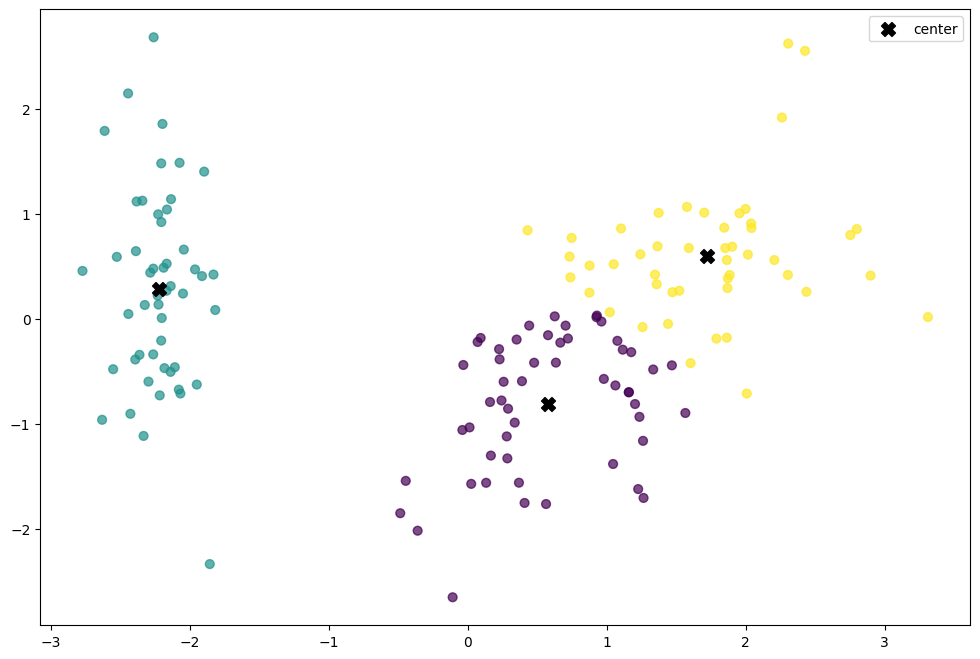

In [12]:
# 군집의 상황을 2차원 그래프로 시각화 -> 차원 축소 
pca = PCA(n_components=2)
# 4차원 데이터를 2차원으로 차원 축소
x_pca = pca.fit_transform(x_std)
# 중심점을 pca을 이용해서 2차원으로 축소
center_pca = pca.transform(model.cluster_centers_)

plt.figure(figsize=(12, 8))

# 독립변수들의 산점도 그래프
plt.scatter(
    x_pca[:, 0], x_pca[:, 1], c = labels, cmap = 'viridis', 
    s = 40, alpha=0.7
)
# 중심점을 산점도 
plt.scatter(
    center_pca[:, 0], center_pca[:, 1], c = 'black', s = 100, 
    marker = 'X', label = 'center'
)

plt.legend()
plt.show()



In [13]:
# bodyperformance 데이터를 이용한 군집 
df = pd.read_csv("../data/bodyPerformance.csv")

In [14]:
df.head(3)

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C


In [15]:
from sklearn.preprocessing import LabelEncoder

In [18]:
# labelencoding 하려는 컬럼들이 다수 존재한다면 -> object형 컬럼의 이름들을 모두 추출
obj_cols = df.select_dtypes('object').columns

In [20]:
for col in obj_cols:
    # print(col)
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [21]:
df.head(3)

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,1,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,2
1,25.0,1,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,0
2,31.0,1,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,2


In [31]:
# 범주형 데이터들을 제외한 독립 변수를 생성 
x = df.drop( ['gender', 'class'], axis=1 )
y1 = df['class']
y2 = df['gender']

In [32]:
x_std = StandardScaler().fit_transform(x)

In [33]:
# 검증 지표 (실루엣 점수) 확인 
# 군집의 개수는 2부터 10개 까지 확인 
# 검증 지표들을 하나의 리스트에 저장 
rows = []

for k in range(2, 11):
    # k -> 군집의 개수 
    km = KMeans(n_clusters=k, n_init = 10, random_state=42)
    pred = km.fit_predict(x_std)
    # 검증 지표 
    iner = km.inertia_
    sil = silhouette_score(x_std, pred)

    row = {
        'K' : k, 
        'inertia' : iner, 
        'silhouette' : sil
    }
    rows.append(row)

In [34]:
scores = pd.DataFrame(rows)
scores.sort_values('silhouette', ascending=False)

,K,inertia,silhouette
0,2,92209.116383,0.285521
1,3,80763.188170,0.212558
2,4,71405.576102,0.200472
4,6,62240.243243,0.176855
3,5,66252.724674,0.172895
5,7,59232.077009,0.159284
6,8,57055.449406,0.150871
7,9,55019.760843,0.143290
8,10,53510.303369,0.134315


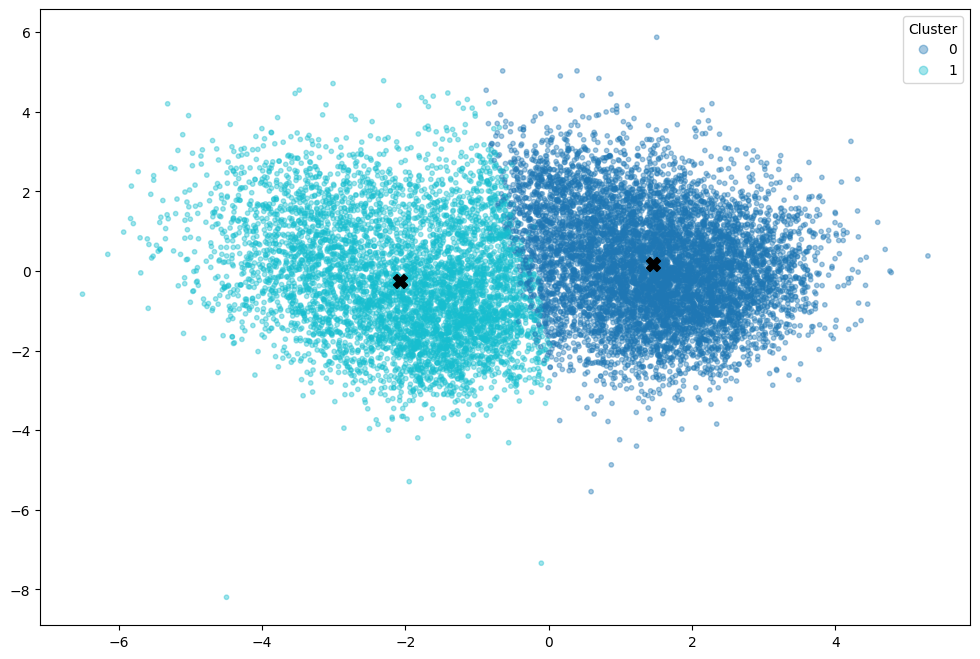

In [43]:
# 군집의 개수가 2인 경우 중심점과 차원축소로 2차원의 데이터의 분포도 
pca = PCA(n_components=2, random_state=42)
# 2차원으로 차원 축소
x_pca = pca.fit_transform(x_std)

km_best = KMeans(n_clusters=2, n_init=10, random_state=42).fit(x_std)

labels_best = km_best.labels_
center_best = km_best.cluster_centers_
# 중심점을 2차원으로 축소
center_pca = pca.transform(center_best)

plt.figure(figsize=(12, 8))

sc = plt.scatter(x_pca[:, 0], x_pca[:, 1], c = labels_best, s = 10, cmap='tab10', alpha=0.4)

plt.scatter(center_pca[:, 0], center_pca[:, 1], c = 'black', s = 100, 
            marker = 'X', label='cneter')

plt.legend(*sc.legend_elements(), title = 'Cluster')
plt.show()



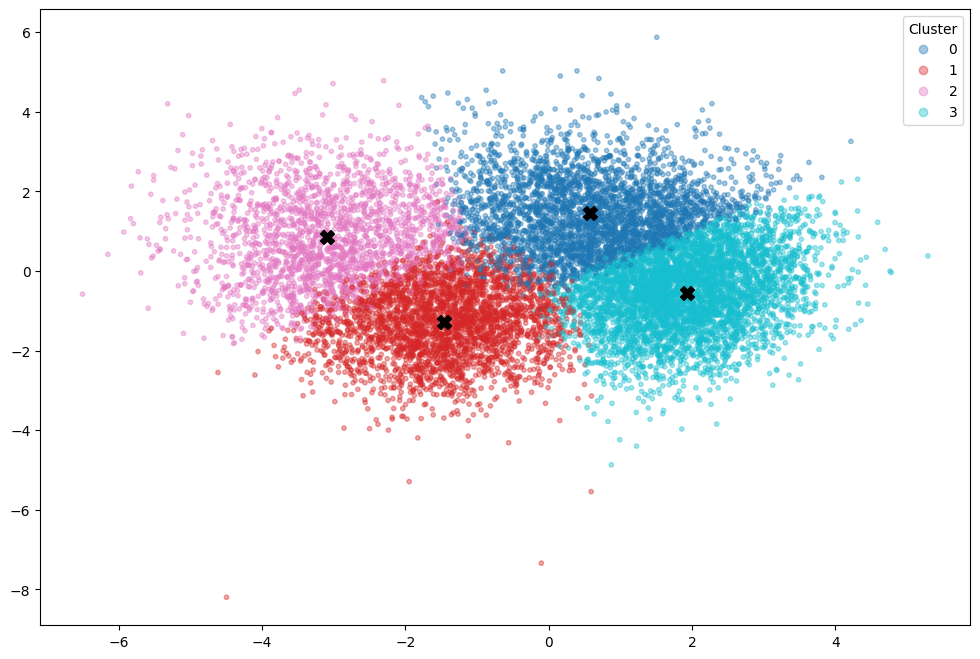

In [44]:
# 군집의 개수가 2인 경우 중심점과 차원축소로 2차원의 데이터의 분포도 
pca = PCA(n_components=2, random_state=42)
# 2차원으로 차원 축소
x_pca = pca.fit_transform(x_std)

km_best = KMeans(n_clusters=4, n_init=10, random_state=42).fit(x_std)

labels_best = km_best.labels_
center_best = km_best.cluster_centers_
# 중심점을 2차원으로 축소
center_pca = pca.transform(center_best)

plt.figure(figsize=(12, 8))

sc = plt.scatter(x_pca[:, 0], x_pca[:, 1], c = labels_best, s = 10, cmap='tab10', alpha=0.4)

plt.scatter(center_pca[:, 0], center_pca[:, 1], c = 'black', s = 100, 
            marker = 'X', label='cneter')

plt.legend(*sc.legend_elements(), title = 'Cluster')
plt.show()



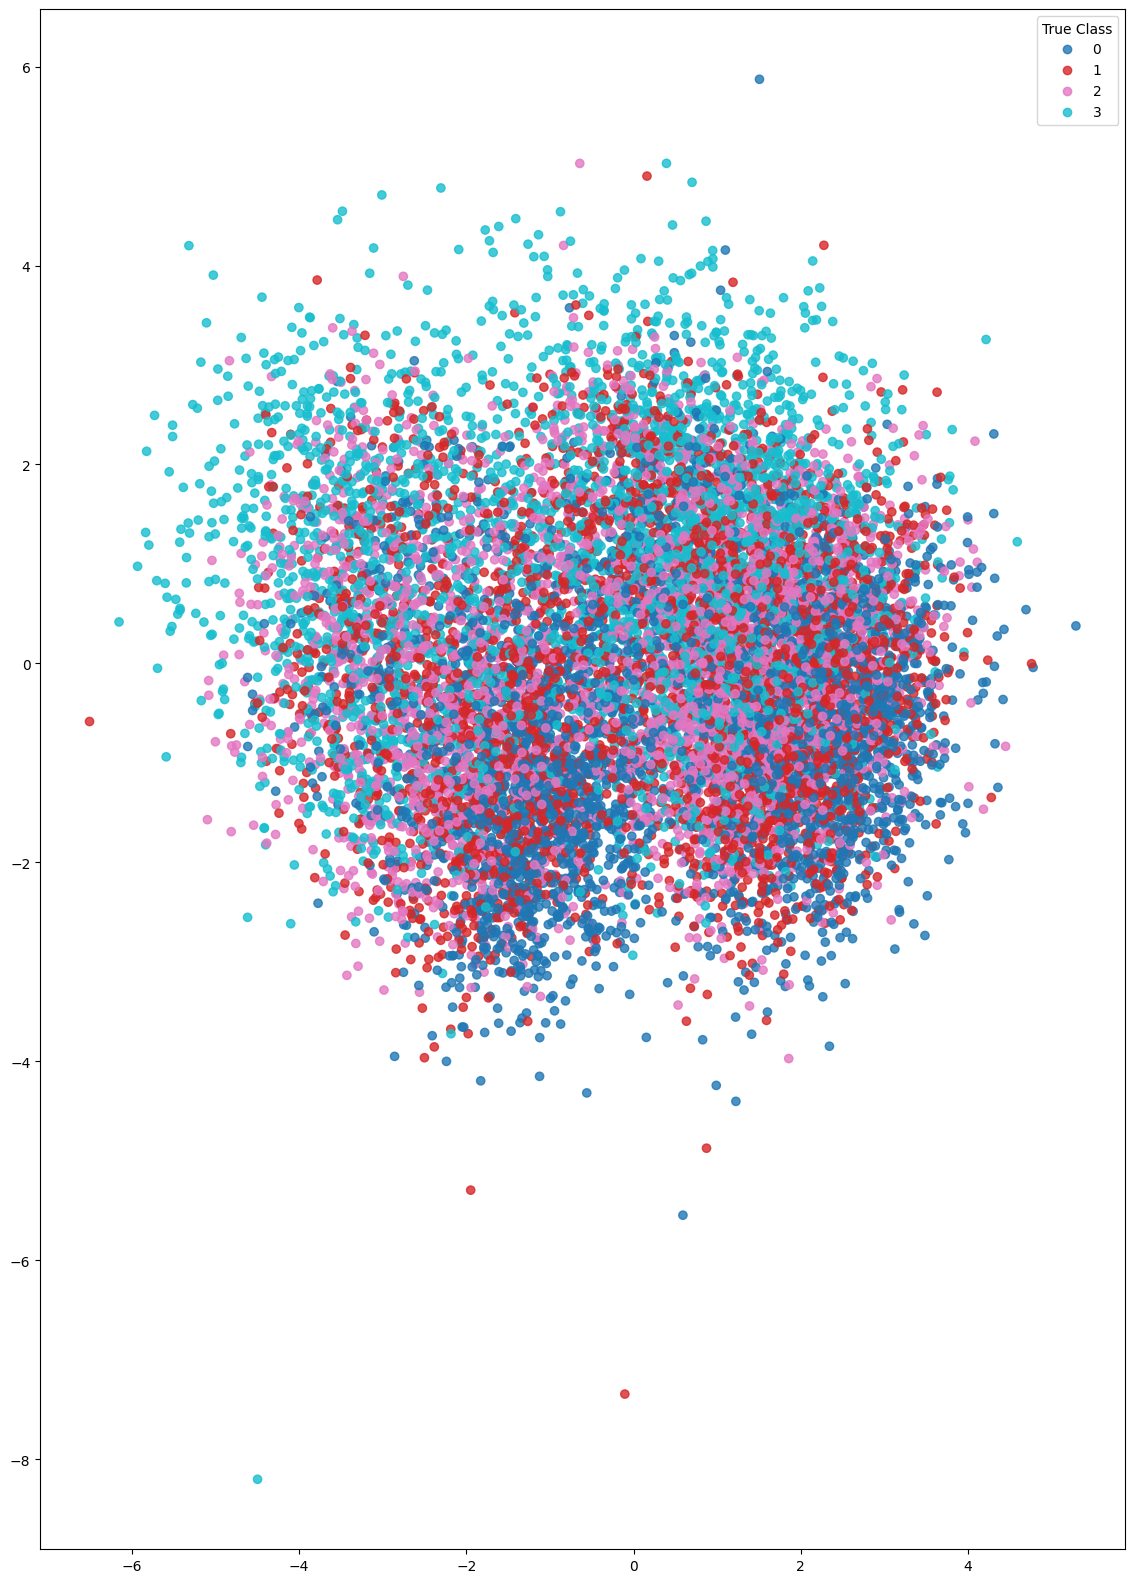

In [46]:
# class컬럼 별 데이터의 분포를 확인 
plt.figure(figsize=(14, 20))

sc_class = plt.scatter(
    x_pca[:, 0], x_pca[:, 1], c = y1, cmap='tab10', alpha = 0.8
)

plt.legend(*sc_class.legend_elements(), title = 'True Class')

plt.show()

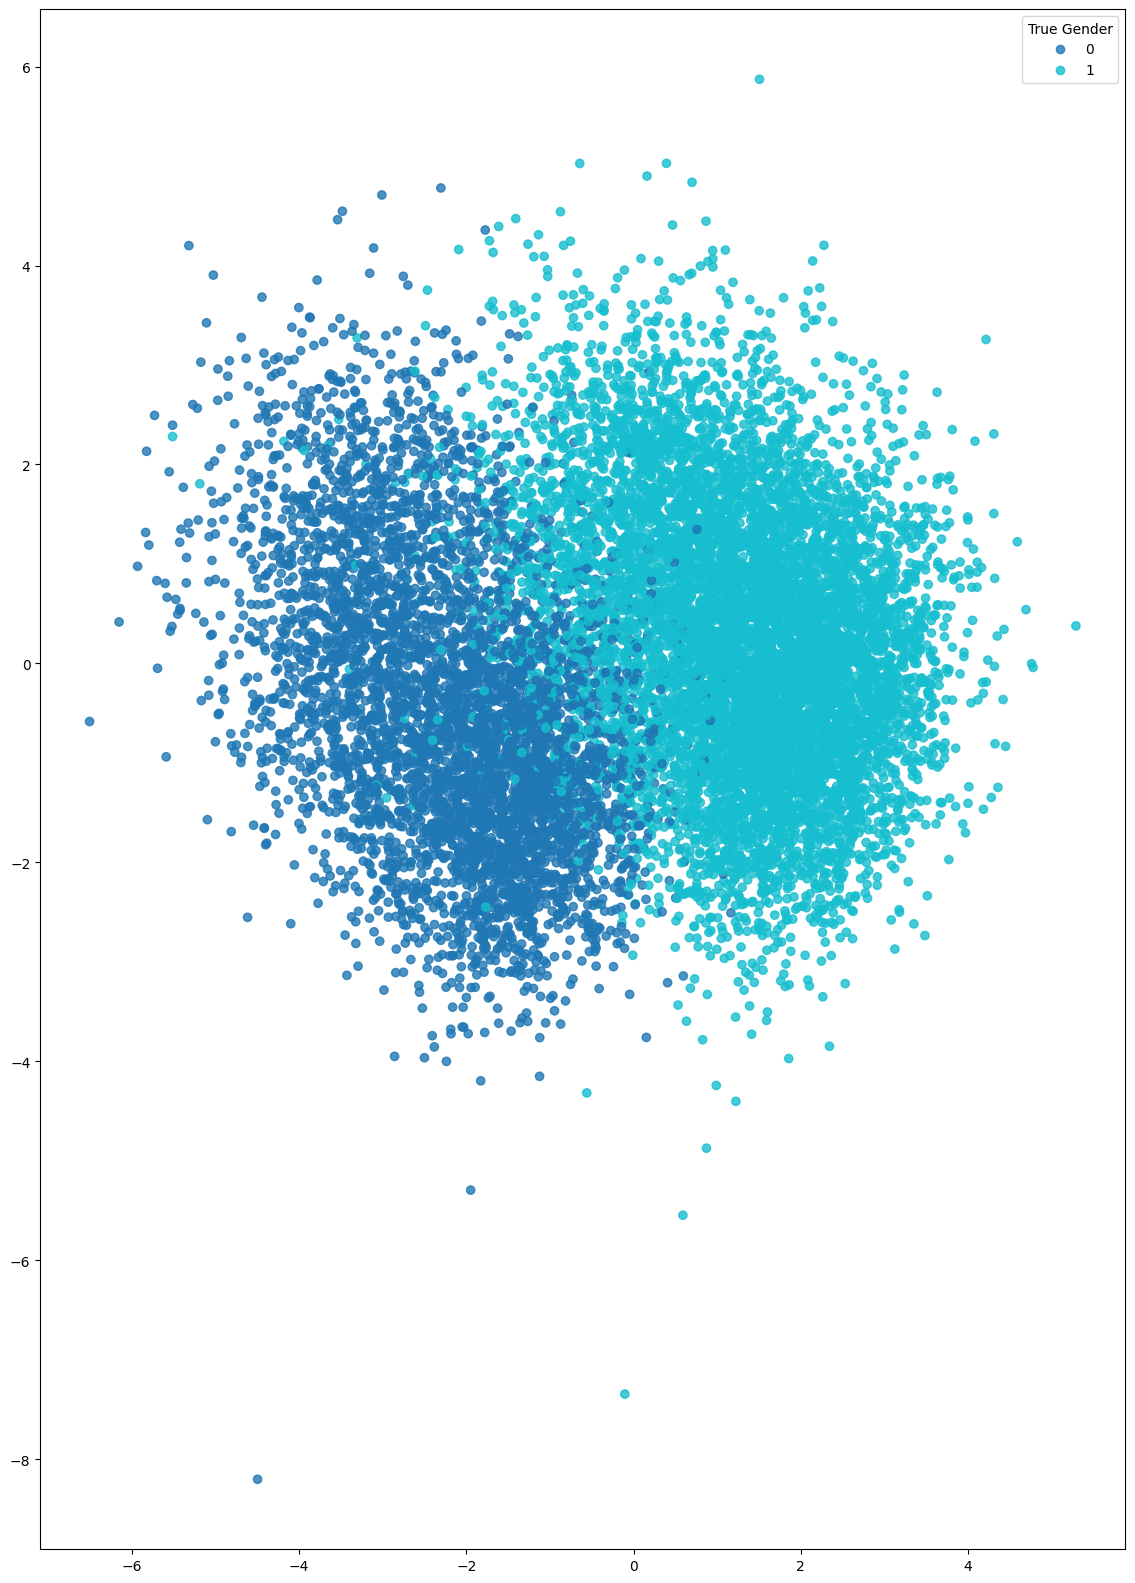

In [47]:
# class컬럼 별 데이터의 분포를 확인 
plt.figure(figsize=(14, 20))

sc_class = plt.scatter(
    x_pca[:, 0], x_pca[:, 1], c = y2, cmap='tab10', alpha = 0.8
)

plt.legend(*sc_class.legend_elements(), title = 'True Gender')

plt.show()